In [167]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score,
    RocCurveDisplay,
    ConfusionMatrixDisplay
)

sns.set(style="whitegrid", context="notebook")

In [168]:
df=pd.read_csv("heart_disease_uci.csv")
df.head(10)

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
5,6,56,Male,Cleveland,atypical angina,120.0,236.0,False,normal,178.0,False,0.8,upsloping,0.0,normal,0
6,7,62,Female,Cleveland,asymptomatic,140.0,268.0,False,lv hypertrophy,160.0,False,3.6,downsloping,2.0,normal,3
7,8,57,Female,Cleveland,asymptomatic,120.0,354.0,False,normal,163.0,True,0.6,upsloping,0.0,normal,0
8,9,63,Male,Cleveland,asymptomatic,130.0,254.0,False,lv hypertrophy,147.0,False,1.4,flat,1.0,reversable defect,2
9,10,53,Male,Cleveland,asymptomatic,140.0,203.0,True,lv hypertrophy,155.0,True,3.1,downsloping,0.0,reversable defect,1


In [169]:
df.columns

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')

In [170]:
df.isnull().sum().sort_values(ascending=False)

ca          611
thal        486
slope       309
fbs          90
oldpeak      62
trestbps     59
exang        55
thalch       55
chol         30
restecg       2
cp            0
dataset       0
id            0
age           0
sex           0
num           0
dtype: int64

In [171]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [172]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [173]:
df.shape

(920, 16)

In [174]:
missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False).round(1)
missing_pct

ca          66.4
thal        52.8
slope       33.6
fbs          9.8
oldpeak      6.7
trestbps     6.4
exang        6.0
thalch       6.0
chol         3.3
restecg      0.2
cp           0.0
dataset      0.0
id           0.0
age          0.0
sex          0.0
num          0.0
dtype: float64

In [175]:
# Convert to binary target: 1 indicates any presence of disease
df['target'] = (df['num'] > 0).astype(int)

# Inspect class balance
class_counts = df['target'].value_counts().sort_index()
class_pct = (class_counts / len(df) * 100).round(1)
pd.DataFrame({
    'target': ['No disease', 'Disease present'],
    'count': class_counts.values,
    'percent': class_pct.values
})

,target,count,percent
0,No disease,411,44.7
1,Disease present,509,55.3


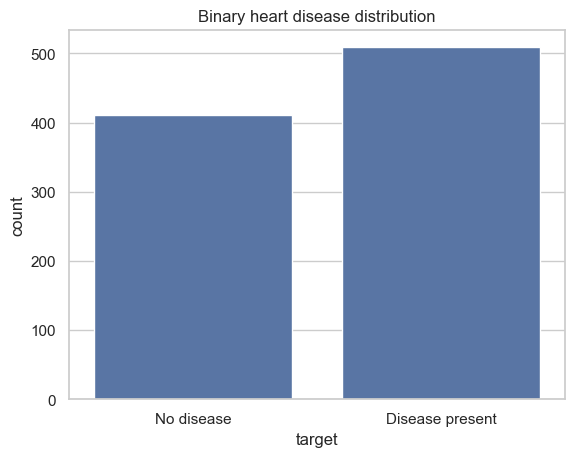

In [176]:
sns.countplot(x="target", data=df)
plt.title("Binary heart disease distribution")
plt.xticks([0, 1], ["No disease", "Disease present"])
plt.show()

## Train/test split with binary target

In [177]:
feature_cols = df.columns.difference(['id', 'num', 'target'])
X = df[feature_cols].copy()
y = df['target']

print(f"Feature matrix shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts(normalize=True).round(3)}")
X.head()

Feature matrix shape: (920, 14)
Target distribution:
target
1    0.553
0    0.447
Name: proportion, dtype: float64


,age,ca,chol,cp,dataset,exang,fbs,oldpeak,restecg,sex,slope,thal,thalch,trestbps
0,63,0.0,233.0,typical angina,Cleveland,False,True,2.3,lv hypertrophy,Male,downsloping,fixed defect,150.0,145.0
1,67,3.0,286.0,asymptomatic,Cleveland,True,False,1.5,lv hypertrophy,Male,flat,normal,108.0,160.0
2,67,2.0,229.0,asymptomatic,Cleveland,True,False,2.6,lv hypertrophy,Male,flat,reversable defect,129.0,120.0
3,37,0.0,250.0,non-anginal,Cleveland,False,False,3.5,normal,Male,downsloping,normal,187.0,130.0
4,41,0.0,204.0,atypical angina,Cleveland,False,False,1.4,lv hypertrophy,Female,upsloping,normal,172.0,130.0


In [178]:
y.head()

0    0
1    1
2    1
3    0
4    0
Name: target, dtype: int64

In [179]:
y.head(3)

0    0
1    1
2    1
Name: target, dtype: int64

In [180]:
y.shape

(920,)

In [181]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Positive rate -> train: {y_train.mean():.3f}, test: {y_test.mean():.3f}")

Train shape: (736, 14), Test shape: (184, 14)
Positive rate -> train: 0.553, test: 0.554


In [182]:
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Numeric features ({len(numeric_features)}): {numeric_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")

Numeric features (6): ['age', 'ca', 'chol', 'oldpeak', 'thalch', 'trestbps']
Categorical features (8): ['cp', 'dataset', 'exang', 'fbs', 'restecg', 'sex', 'slope', 'thal']


In [183]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

preprocess

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'ca', 'chol', 'oldpeak', 'thalch',
                                  'trestbps']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['cp', 'dataset', 'exang', 'fbs', 'restecg',
                                  'sex', 'slope', 'thal'])])

### Logistic regression baseline (pipeline + cross-validation)
The pipeline below handles preprocessing, tunes class weighting for imbalance, and evaluates with stratified 5-fold CV before testing on the held-out set.

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

log_reg = Pipeline(
    steps=[
        ("preprocess", preprocess),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                solver="liblinear",
                C=1.0
            ),
        ),
    ]
)

log_cv_scores = cross_val_score(log_reg, X_train, y_train, cv=cv, scoring="roc_auc")
print(f"Logistic Regression CV ROC-AUC: {log_cv_scores.mean():.3f} ± {log_cv_scores.std():.3f}")

log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)
y_proba = log_reg.predict_proba(X_test)[:, 1]

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["No disease", "Disease"]))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

print("ROC-AUC (test):", roc_auc_score(y_test, y_proba))
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.show()

Logistic Regression CV ROC-AUC: 0.900 ± 0.015
Test Accuracy: 0.8478260869565217
              precision    recall  f1-score   support

  No disease       0.84      0.82      0.83        82
     Disease       0.86      0.87      0.86       102

    accuracy                           0.85       184
   macro avg       0.85      0.84      0.85       184
weighted avg       0.85      0.85      0.85       184



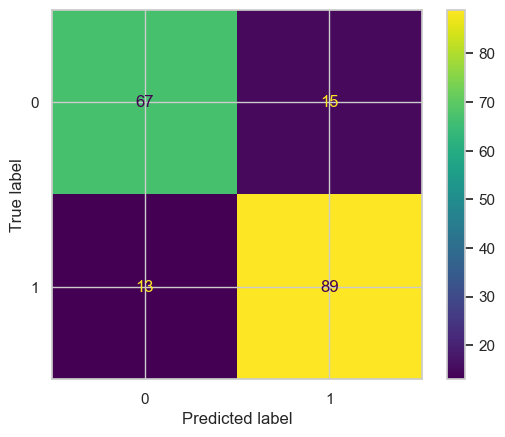

ROC-AUC (test): 0.919894787183166


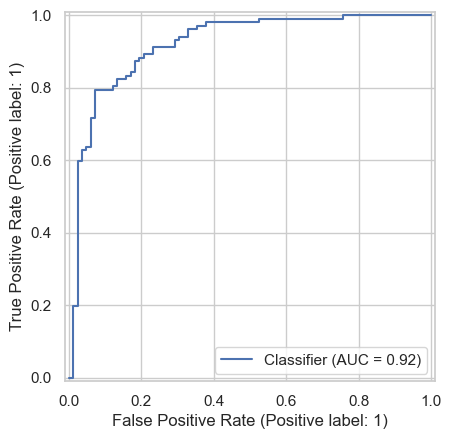

In [184]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

log_reg = Pipeline(
    steps=[
        ("preprocess", preprocess),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                solver="liblinear",
                C=1.0,
            ),
        ),
    ]
)

log_cv_scores = cross_val_score(log_reg, X_train, y_train, cv=cv, scoring="roc_auc")
print(f"Logistic Regression CV ROC-AUC: {log_cv_scores.mean():.3f} ± {log_cv_scores.std():.3f}")

log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)
y_proba = log_reg.predict_proba(X_test)[:, 1]

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["No disease", "Disease"]))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

print("ROC-AUC (test):", roc_auc_score(y_test, y_proba))
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.show()

### RandomForest baseline (pipeline + cross-validation)
Run the same preprocessing pipeline with a tree-based model. Trees don’t need scaling, but we keep the shared pipeline for consistent handling of missing values and categoricals.

RandomForest CV ROC-AUC: 0.887 ± 0.025
Test Accuracy: 0.8695652173913043
              precision    recall  f1-score   support

  No disease       0.88      0.82      0.85        82
     Disease       0.86      0.91      0.89       102

    accuracy                           0.87       184
   macro avg       0.87      0.86      0.87       184
weighted avg       0.87      0.87      0.87       184



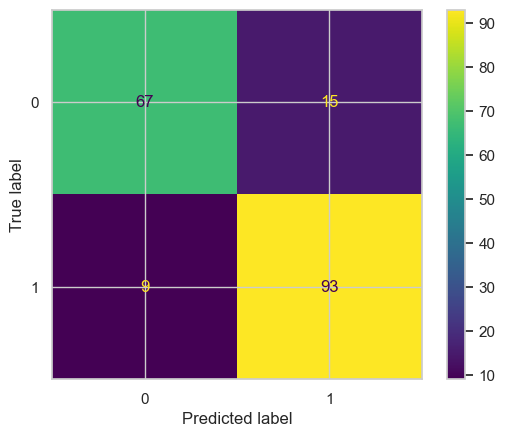

ROC-AUC (test): 0.9317312290769966


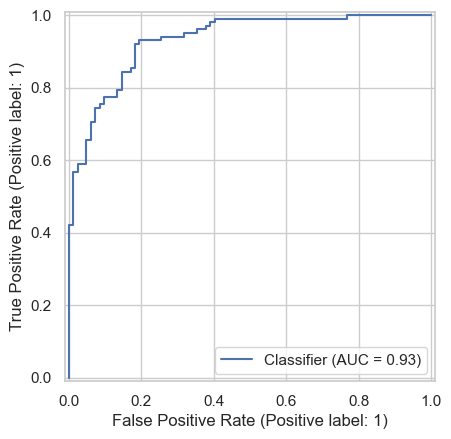

In [185]:
rf_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=None,
                min_samples_leaf=2,
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

rf_cv_scores = cross_val_score(rf_pipe, X_train, y_train, cv=cv, scoring="roc_auc")
print(f"RandomForest CV ROC-AUC: {rf_cv_scores.mean():.3f} ± {rf_cv_scores.std():.3f}")

rf_pipe.fit(X_train, y_train)
rf_pred = rf_pipe.predict(X_test)
rf_proba = rf_pipe.predict_proba(X_test)[:, 1]

print("Test Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred, target_names=["No disease", "Disease"]))
ConfusionMatrixDisplay.from_predictions(y_test, rf_pred)
plt.show()

print("ROC-AUC (test):", roc_auc_score(y_test, rf_proba))
RocCurveDisplay.from_predictions(y_test, rf_proba)
plt.show()

_Legacy training cells below have been disabled. Use the pipeline sections above to fit/evaluate models._

In [186]:
print("Legacy RandomForest cell removed. Run the RandomForest pipeline above for training/prediction.")

Legacy RandomForest cell removed. Run the RandomForest pipeline above for training/prediction.


In [187]:
# Ecvalyte the model

from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))


Accuracy: 0.8478260869565217
[[67 15]
 [13 89]]
              precision    recall  f1-score   support

           0       0.84      0.82      0.83        82
           1       0.86      0.87      0.86       102

    accuracy                           0.85       184
   macro avg       0.85      0.84      0.85       184
weighted avg       0.85      0.85      0.85       184



In [188]:
# RandomForest legacy snippet removed to prevent preprocessing errors.
print("Use the RandomForest pipeline cell above (rf_pipe) to train and evaluate.")

Use the RandomForest pipeline cell above (rf_pipe) to train and evaluate.
